In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)

In [ ]:
IMAGE_SIZE = 64
SAMPLES_PER_CLASS = 25

def add_noise(image, amount=15):
    noise = np.random.randint(-amount, amount, image.shape)
    noisy_image = image.astype(int) + noise
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image.astype(np.uint8)

def make_horizontal_stripes(size):
    image = np.zeros((size, size), dtype=np.uint8)
    for row in range(size):
        if (row // 4) % 2 == 0:
            image[row, :] = 220
        else:
            image[row, :] = 40
    return add_noise(image)

def make_vertical_stripes(size):
    image = np.zeros((size, size), dtype=np.uint8)
    for col in range(size):
        if (col // 4) % 2 == 0:
            image[:, col] = 220
        else:
            image[:, col] = 40
    return add_noise(image)

def make_checkerboard(size, block=8):
    image = np.zeros((size, size), dtype=np.uint8)
    for row in range(size):
        for col in range(size):
            if ((row // block) + (col // block)) % 2 == 0:
                image[row, col] = 220
            else:
                image[row, col] = 40
    return add_noise(image)

def make_random_dots(size):
    image = np.random.randint(0, 256, (size, size)).astype(np.uint8)
    return image

class_names = ["Horizontal Stripes", "Vertical Stripes", "Checkerboard", "Random Dots"]

images = []
labels = []

for _ in range(SAMPLES_PER_CLASS):
    images.append(make_horizontal_stripes(IMAGE_SIZE)); labels.append(0)
    images.append(make_vertical_stripes(IMAGE_SIZE));   labels.append(1)
    images.append(make_checkerboard(IMAGE_SIZE));       labels.append(2)
    images.append(make_random_dots(IMAGE_SIZE));        labels.append(3)

print("Total images created:", len(images))
print("Classes:", class_names)


Total images created: 100
Classes: ['Horizontal Stripes', 'Vertical Stripes', 'Checkerboard', 'Random Dots']


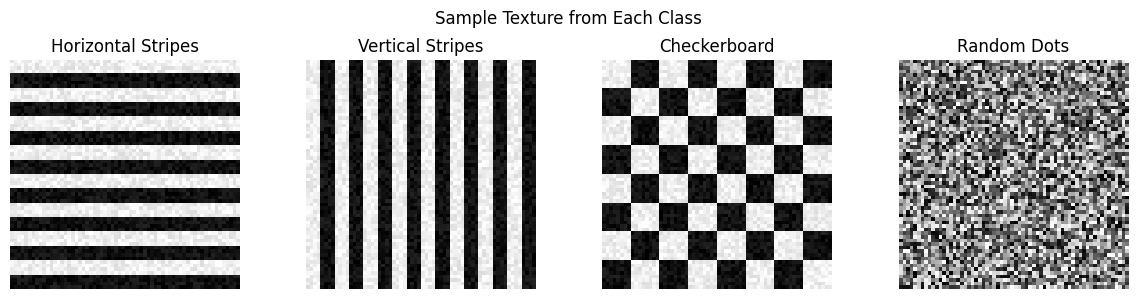

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))


for class_id in range(4):
    index = labels.index(class_id)
    axes[class_id].imshow(images[index], cmap='gray')
    axes[class_id].set_title(class_names[class_id])
    axes[class_id].axis('off')

plt.suptitle("Sample Texture from Each Class")
plt.tight_layout()
plt.show()


In [ ]:
GRAY_LEVELS = 8

def extract_glcm_features(image):
    """Return a list of 5 simple texture features for one image."""
    reduced_image = (image // (256 // GRAY_LEVELS)).astype(np.uint8)

    glcm = graycomatrix(reduced_image,
                         distances=[1],
                         angles=[0],
                         levels=GRAY_LEVELS,
                         symmetric=True,
                         normed=True)

    contrast = graycoprops(glcm, 'contrast')[0, 0]
    dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]

    return [contrast, dissimilarity, homogeneity, energy, correlation]

feature_list = []
for image in images:
    feature_list.append(extract_glcm_features(image))

print("Features extracted for", len(feature_list), "images")
print("Example feature vector:", feature_list[0])


Features extracted for 100 images
Example feature vector: [np.float64(0.4186507936507936), np.float64(0.4186507936507936), np.float64(0.7906746031746033), np.float64(0.41284855124903136), np.float64(0.974223797267635)]


In [ ]:
feature_names = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']

df = pd.DataFrame(feature_list, columns=feature_names)
df['label'] = labels
df['class_name'] = df['label'].apply(lambda x: class_names[x])

df.head(10)


,contrast,dissimilarity,homogeneity,energy,correlation,label,class_name
0,0.418651,0.418651,0.790675,0.412849,0.974224,0,Horizontal Stripes
1,7.877232,1.649554,0.611401,0.333622,0.512014,1,Vertical Stripes
2,3.920139,1.002976,0.702340,0.372098,0.756281,2,Checkerboard
3,10.577133,2.633681,0.298934,0.125840,-0.007386,3,Random Dots
4,0.392609,0.392609,0.803695,0.424225,0.975486,0,Horizontal Stripes
5,7.926339,1.650050,0.613227,0.329982,0.511239,1,Vertical Stripes
6,3.845982,0.972470,0.715761,0.378428,0.759060,2,Checkerboard
7,10.390377,2.607639,0.303334,0.125558,-0.001566,3,Random Dots
8,0.406250,0.406250,0.796875,0.419229,0.974607,0,Horizontal Stripes
9,7.920883,1.650546,0.612850,0.333043,0.508271,1,Vertical Stripes


/tmp/ipykernel_540/3708773287.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_per_class, labels=class_names)
/tmp/ipykernel_540/3708773287.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_per_class, labels=class_names)
/tmp/ipykernel_540/3708773287.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_per_class, labels=class_names)
/tmp/ipykernel_540/3708773287.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(

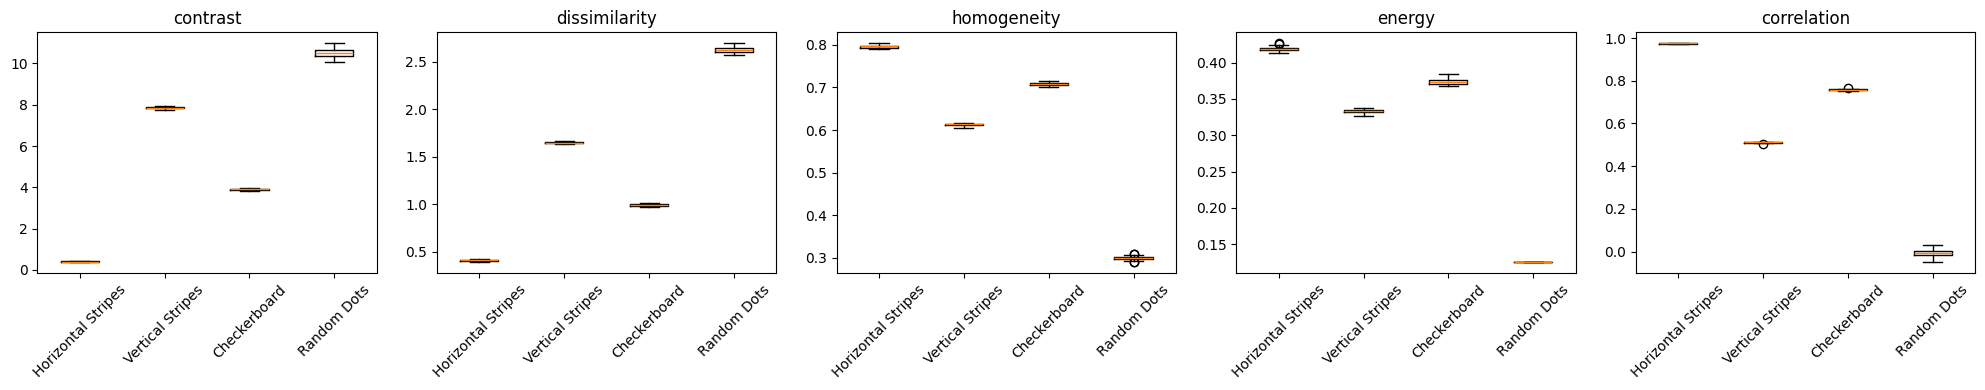

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, feature in enumerate(feature_names):
    data_per_class = [df[df['label'] == c][feature] for c in range(4)]
    axes[i].boxplot(data_per_class, labels=class_names)
    axes[i].set_title(feature)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
X = df[feature_names].values
y = df['label'].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 80
Testing samples: 20


In [ ]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")


Accuracy: 100.0 %


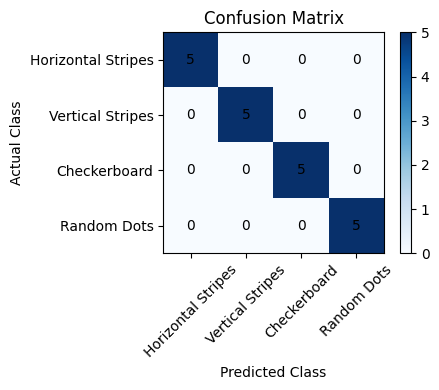

                    precision    recall  f1-score   support

Horizontal Stripes       1.00      1.00      1.00         5
  Vertical Stripes       1.00      1.00      1.00         5
      Checkerboard       1.00      1.00      1.00         5
       Random Dots       1.00      1.00      1.00         5

          accuracy                           1.00        20
         macro avg       1.00      1.00      1.00        20
      weighted avg       1.00      1.00      1.00        20



In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(range(4), class_names, rotation=45)
plt.yticks(range(4), class_names)


for i in range(4):
    for j in range(4):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.colorbar()
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=class_names))


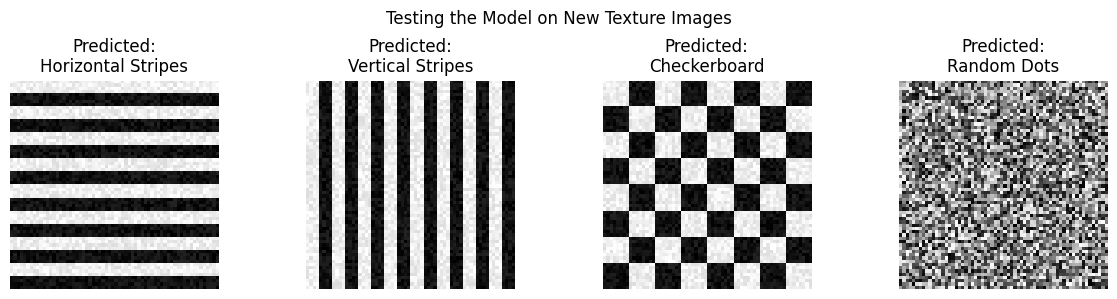

In [ ]:
new_images = [
    make_horizontal_stripes(IMAGE_SIZE),
    make_vertical_stripes(IMAGE_SIZE),
    make_checkerboard(IMAGE_SIZE),
    make_random_dots(IMAGE_SIZE),
]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for i, image in enumerate(new_images):
    features = extract_glcm_features(image)
    predicted_label = model.predict([features])[0]

    axes[i].imshow(image, cmap='gray')
    axes[i].set_title("Predicted:\n" + class_names[predicted_label])
    axes[i].axis('off')

plt.suptitle("Testing the Model on New Texture Images")
plt.tight_layout()
plt.show()
